In [2]:
import arcgis
import fastai
import torch

In [3]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [4]:
from arcgis.learn import prepare_data, SingleShotDetector
from fastai.vision.data import ImageDataBunch

In [9]:
rgb_path = r'/mnt/Raster/Data/Tests_Data/object_detection/data2'

In [6]:
data = prepare_data(rgb_path, batch_size=4, class_mapping={'1': 'palm', '2': 'houses'})

In [7]:
data

ImageDataBunch;

Train: LabelList (144 items)
x: ObjectDetectionItemList
ArcGISMSImage (3, 224, 224),ArcGISMSImage (3, 224, 224),ArcGISMSImage (3, 224, 224),ArcGISMSImage (3, 224, 224),ArcGISMSImage (3, 224, 224)
y: ObjectDetectionCategoryList
ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224)
Path: \\ndhfs1\Raster\Data\Tests_Data\object_detection\data2\images;

Valid: LabelList (16 items)
x: ObjectDetectionItemList
ArcGISMSImage (3, 224, 224),ArcGISMSImage (3, 224, 224),ArcGISMSImage (3, 224, 224),ArcGISMSImage (3, 224, 224),ArcGISMSImage (3, 224, 224)
y: ObjectDetectionCategoryList
ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224)
Path: \\ndhfs1\Raster\Data\Tests_Data\object_detection\data2\images;

Test: None

In [8]:
assert isinstance(data, ImageDataBunch)

In [9]:
data.class_mapping

{1: 'palm', 2: 'houses'}

In [10]:
assert isinstance(data.class_mapping, dict)

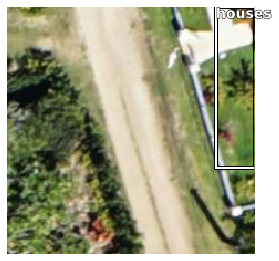

In [14]:
data.show_batch(rows=1)

In [15]:
model = SingleShotDetector(data)

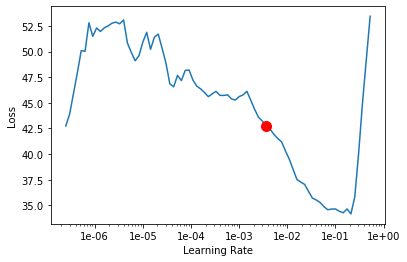

0.00363078054770101

In [16]:
model.lr_find()

In [17]:
model.fit(10)

epoch,train_loss,valid_loss,time
0,43.877079,17.607857,00:46
1,29.238342,10.555637,01:03
2,20.423729,9.573433,00:59
3,16.742977,9.688017,00:44
4,15.038170,9.209651,00:43
5,13.730594,8.864777,00:47
6,13.111351,8.930882,00:58
7,12.961052,8.750830,01:02
8,11.977097,8.556658,00:52
9,12.111259,8.240195,00:48


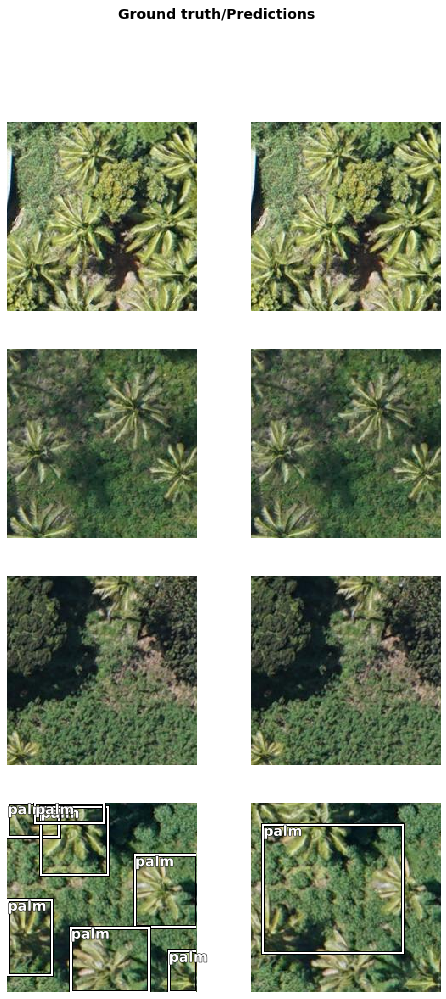

In [18]:
model.show_results()

In [12]:
model.save(r'/home/administrator/Raster/notebook_test_model')

WindowsPath('//ndhfs1/Raster/Data/testdata/extracted_data/object_detection_data/palm-tree-256/models/fastTest')

In [19]:
score = model.average_precision_score()

In [22]:
score.get('palm')

0.4287096651018021

In [25]:
assert score.get('palm') >= 0.4